In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [14]:
data = pd.read_csv("Social_Network_Ads-selected-columns.csv")

X = data[['Age', 'EstimatedSalary']]
y = data['Purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    random_state=55,
    test_size=0.2
)

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.8375

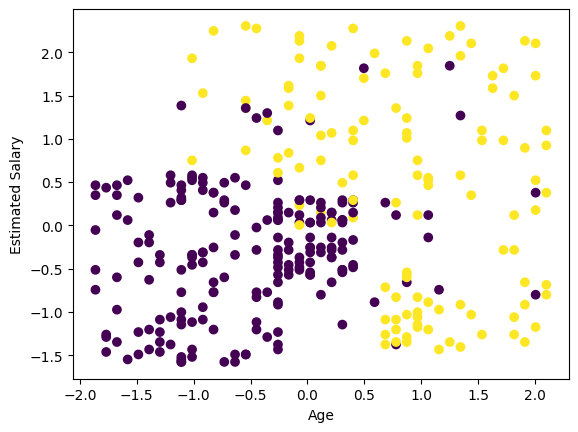

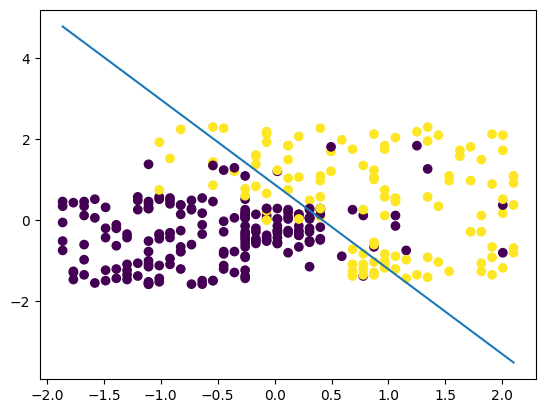

In [29]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.show()

w = model.coef_[0]
b = model.intercept_[0]

x = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 100)

y = -(w[0] * x + b) / w[1]

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.plot(x, y)

In [30]:
model = SVC(kernel='rbf')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.925


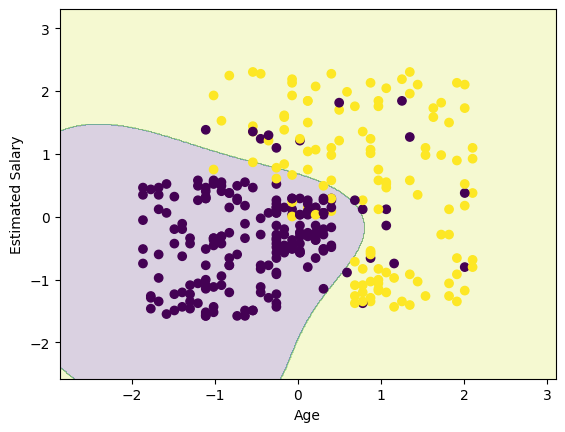

In [31]:
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.2)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.show()